## Guillespie Simulations for Poisson hypergraph


This notebook genereated the stocastic simualtion used to create the phase diagram of SIS process in a hypegraph with Poisson hyperdegree distribution and uncorrelted cross-order correlation used in figure 2 of the paper 'Unveiling the impact of cross-order hyperdegree correlations in contagion processes on hypergraphs'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time
import sys, os


In [4]:
sys.path.insert(1,'../Libraries/')

from Configurational_model_HO import* #one for the configurational mdoel and another
from Overlap_func import* #for calcualte overlap of higher order netowks
from HO_effective_degree import* #contains then necesaryt functions for effective hyperdegree

In [6]:
from datetime import datetime
start_time = datetime.now()


#N=500
N=1000
k1=5
k2=3
mu=1

lam1=2.5
lam2=5

beta1=lam1*mu/k1
beta2=lam2*mu/k2

iters=30
num_inf=20
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=15

pairs= np.loadtxt(f'../data/higherorder_networkstructures/poi_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples=np.loadtxt(f'../data/higherorder_networkstructures/poi_triples_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)

init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
times_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=2000, variance_threshold=1e-4)

all_sim=[]
I=I_runs[0]

#epidemic_size=epidemic_size/iters
#rint('Epidemic_size ', epidemic_size)
#data_runs=[times_runs,I_runs]
#data_runs_arr=np.array(data_runs, dtype=object)
#file_name=f'sim_N{N}_k1{k1}_k2{k2}'
#np.savetxt('regular_simulation/'+file_name+'.txt',data_sim)


end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))


Duration: 0:00:05.033754


IndexError: list index out of range

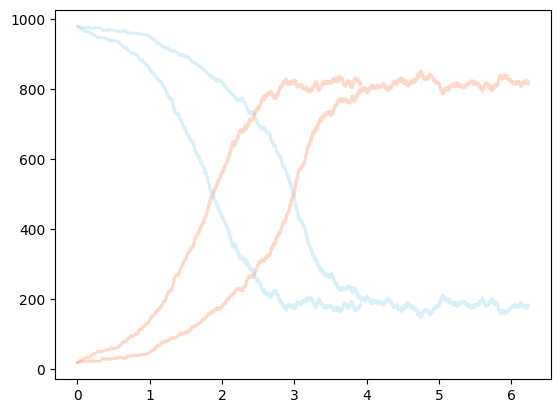

In [7]:
# plt.title(r'Regular $k_1=4, k_2=2$')

N=1000
k1=8
k2=4

for j in range (30):
    #data_sim=np.loadtxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}_{j}.txt')
    t,S_,I_=times_runs[j],S_runs[j],I_runs[j]
    plt.plot(t,I_,lw=2,color='coral', alpha=0.3)
    plt.plot(t,S_,lw=2,color='skyblue', alpha=0.3)



In [ ]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,2,50)
lambdas = lambdas[::3]
print(lambdas)
#N=500
N=1000
k1=5
k2=3
lam2=2.5
mu=1
beta2=lam2*mu/k2

iters=100
num_inf=20
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=70

pairs= np.loadtxt(f'../data/higherorder_networkstructures/poi_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples=np.loadtxt(f'../data/higherorder_networkstructures/poi_triples_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)


init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

prevalences=[]
I_steady_states1=[]
for lam in lambdas:
    beta1=lam*mu/k1
#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
    times_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=1000, variance_threshold=1e-6)
    
    all_sim=[]
    epidemic_size=[]
    for i in range (len(I_runs)):
        I=I_runs[i]
        times=times_runs[i]
        #minio_helper.save_file(f'Simulation_Poisson_HO_alpha0/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim_arr, obj_type='csv' )
        epidemic_size.append(np.mean(I[-100:]))
        #np.savetxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim)

    
    I_steady_states1.append(epidemic_size)
    print(f'Lambda=  {lam}, Epidemic_size = {np.mean(epidemic_size)}, final time {times[-1]} ')

    prevalences.append(np.mean(epidemic_size))
#data_runs=[times_runs,I_runs]
#data_runs_arr=np.array(data_runs, dtype=object)
#file_name=f'sim_N{N}_k1{k1}_k2{k2}'
#np.savetxt('regular_simulation/'+file_name+'.txt',data_sim)

#minio_helper.save_file(f'Simulation_Poisson_HO/sim_N{N}_k1{k1}_k2{k2}'+f'_I_ss'+'.txt',pd.DataFrame(I_steady_states1), obj_type='csv' )
#minio_helper.save_file(f'Simulation_Poisson_HO/sim_N{N}_k1{k1}_k2{k2}'+f'_prev_reverse'+'.txt',pd.DataFrame(prevalences), obj_type='csv' )
end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))




[1.00000000e-03 1.23387755e-01 2.45775510e-01 3.68163265e-01
 4.90551020e-01 6.12938776e-01 7.35326531e-01 8.57714286e-01
 9.80102041e-01 1.10248980e+00 1.22487755e+00 1.34726531e+00
 1.46965306e+00 1.59204082e+00 1.71442857e+00 1.83681633e+00
 1.95920408e+00]
Lambda=  0.001, Epidemic_size = 10.103441704237486, final time 2.284774580100625 
Lambda=  0.12338775510204081, Epidemic_size = 10.435748986698293, final time 2.5605347225915405 
Lambda=  0.24577551020408162, Epidemic_size = 10.576652320068796, final time 3.9937441529803044 
Lambda=  0.3681632653061224, Epidemic_size = 10.927988551185017, final time 3.733988188686232 


/tmp/ipykernel_1325916/639334815.py:25: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../Poisson_structures/poi_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
/tmp/ipykernel_1325916/639334815.py:26: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      

Lambda=  0.49055102040816323, Epidemic_size = 11.0667403416694, final time 2.325582377425981 
Lambda=  0.612938775510204, Epidemic_size = 11.045449362550823, final time 8.332677901846028 
Lambda=  0.7353265306122448, Epidemic_size = 10.47463953828585, final time 6.24771087128865 
Lambda=  0.8577142857142857, Epidemic_size = 10.588527563666865, final time 4.906799960685513 
Lambda=  0.9801020408163265, Epidemic_size = 125.34141639289084, final time 28.22583844297654 
Lambda=  1.1024897959183673, Epidemic_size = 459.4904659897065, final time 70.00026459922772 
Lambda=  1.224877551020408, Epidemic_size = 587.7676393442623, final time 70.00053212688428 
Lambda=  1.3472653061224489, Epidemic_size = 609.0786776119402, final time 70.00076698389103 


IOStream.flush timed out


Lambda=  1.4696530612244896, Epidemic_size = 643.2371999999999, final time 70.00039475727186 
Lambda=  1.5920408163265305, Epidemic_size = 661.4606, final time 70.00091268140088 
Lambda=  1.7144285714285712, Epidemic_size = 676.5518, final time 70.00010490600117 
Lambda=  1.836816326530612, Epidemic_size = 693.1759999999999, final time 70.00019008401028 
Lambda=  1.9592040816326528, Epidemic_size = 701.0332000000001, final time 70.00063812053378 
Duration: 0:20:22.610326


IOStream.flush timed out


In [12]:
I_steady_states1 = [[10.130434782608695, 10.96, 10.0, 10.043478260869565, 10.73913043478261, 10.0, 10.0, 10.391304347826088, 10.0, 11.04, 10.391304347826088, 9.695652173913043, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.652173913043478, 10.0, 10.0, 10.0, 10.0, 10.91304347826087, 10.91304347826087, 10.0, 10.217391304347826, 10.0, 10.478260869565217, 10.826086956521738], [11.518518518518519, 10.043478260869565, 9.434782608695652, 10.0, 10.72, 9.448275862068966, 10.826086956521738, 11.36, 10.0, 9.76, 10.0, 10.91304347826087, 11.903225806451612, 10.925925925925926, 10.0, 10.73913043478261, 10.565217391304348, 10.0, 10.0, 10.217391304347826, 10.0, 10.0, 10.0, 9.862068965517242, 11.12, 10.0, 10.0, 10.806451612903226, 10.91304347826087, 9.695652173913043], [10.391304347826088, 9.347826086956522, 10.24, 11.448275862068966, 9.2, 10.121212121212121, 10.0, 10.0, 10.0, 9.862068965517242, 10.0, 9.586206896551724, 10.481481481481481, 9.88888888888889, 11.914285714285715, 10.08, 10.130434782608695, 10.217391304347826, 9.444444444444445, 11.44, 10.777777777777779, 10.043478260869565, 10.16, 9.26086956521739, 10.72, 10.344827586206897, 10.62962962962963, 9.695652173913043, 10.478260869565217, 10.0], [10.181818181818182, 9.04, 10.555555555555555, 10.130434782608695, 10.826086956521738, 12.0, 10.777777777777779, 9.027027027027026, 9.2, 12.137931034482758, 11.172413793103448, 10.73913043478261, 9.814814814814815, 9.88888888888889, 11.296296296296296, 9.92, 9.76, 10.851851851851851, 10.333333333333334, 11.571428571428571, 11.962962962962964, 9.26086956521739, 12.206896551724139, 10.043478260869565, 9.88888888888889, 9.12, 9.241379310344827, 10.478260869565217, 10.56, 10.787878787878787], [9.869565217391305, 10.11111111111111, 7.696969696969697, 11.17142857142857, 9.869565217391305, 10.161290322580646, 10.407407407407407, 10.942857142857143, 9.521739130434783, 10.407407407407407, 13.325581395348838, 11.405405405405405, 10.407407407407407, 9.241379310344827, 10.185185185185185, 10.0, 9.444444444444445, 11.511627906976743, 9.28, 11.448275862068966, 11.862068965517242, 9.592592592592593, 10.121212121212121, 10.25925925925926, 8.692307692307692, 11.04, 10.925925925925926, 9.871794871794872, 11.135135135135135, 9.8], [10.217391304347826, 8.538461538461538, 11.13953488372093, 9.628571428571428, 8.555555555555555, 12.617021276595745, 10.666666666666666, 8.044444444444444, 11.814814814814815, 10.35483870967742, 11.628571428571428, 10.67741935483871, 11.586206896551724, 10.413793103448276, 11.10344827586207, 12.60377358490566, 10.484848484848484, 8.108108108108109, 12.181818181818182, 8.96551724137931, 10.485714285714286, 11.296296296296296, 10.419354838709678, 12.076923076923077, 10.0, 9.628571428571428, 11.114285714285714, 11.444444444444445, 11.976744186046512, 8.303030303030303], [10.424242424242424, 12.428571428571429, 9.01639344262295, 10.195121951219512, 10.068965517241379, 10.755555555555556, 12.2, 10.851851851851851, 10.787878787878787, 9.903225806451612, 10.32, 12.787878787878787, 9.655172413793103, 8.743589743589743, 9.2, 10.878048780487806, 13.27450980392157, 11.169811320754716, 9.575757575757576, 12.91891891891892, 9.310344827586206, 10.612903225806452, 11.513513513513514, 9.956521739130435, 11.148148148148149, 9.75609756097561, 11.891891891891891, 10.925925925925926, 11.193548387096774, 11.333333333333334], [12.794871794871796, 10.826086956521738, 10.58974358974359, 8.257142857142858, 11.784615384615385, 12.6, 10.88, 11.245901639344263, 9.93939393939394, 9.6, 10.108108108108109, 9.814814814814815, 10.0, 12.432432432432432, 10.62962962962963, 10.0, 10.731707317073171, 11.707317073170731, 9.586206896551724, 11.847457627118644, 10.885714285714286, 10.0, 10.96551724137931, 10.378378378378379, 10.484848484848484, 11.243243243243244, 11.272727272727273, 10.96551724137931, 14.897435897435898, 9.0], [8.348837209302326, 13.042553191489361, 13.512195121951219, 14.89090909090909, 11.205128205128204, 10.314285714285715, 9.580645161290322, 10.631578947368421, 11.114285714285714, 10.11111111111111, 13.186046511627907, 8.195121951219512, 8.191489361702128, 12.806451612903226, 13.07843137254902, 13.549019607843137, 9.512195121951219, 11.96774193548387, 11.10344827586207, 9.325581395348838, 9.4, 11.020408163265307, 11.88, 10.254901960784315, 13.41025641025641, 10.257142857142858, 10.935483870967742, 12.938775510204081, 11.0, 10.741935483870968], [11.962264150943396, 10.484848484848484, 11.129032258064516, 13.170212765957446, 8.767441860465116, 9.135135135135135, 9.471698113207546, 9.031746031746032, 10.085714285714285, 10.065573770491802, 9.804878048780488, 11.60655737704918, 11.518518518518519, 12.96078431372549, 10.767441860465116, 13.051282051282051, 10.568627450980392, 10.097560975609756, 9.755102040816327, 15.481012658227849, 8.142857142857142, 10.311111111111112, 11.090909090909092, 9.307692307692308, 11.268292682926829, 12.407407407407407, 10.121212121212121, 10.756756756756756, 11.114285714285714, 12.627906976744185], [11.169014084507042, 9.757575757575758, 10.555555555555555, 9.93939393939394, 11.051282051282051, 9.774193548387096, 13.677966101694915, 15.08, 9.862745098039216, 7.509090909090909, 11.811764705882354, 7.591836734693878, 11.64406779661017, 9.790697674418604, 15.018867924528301, 9.0, 8.846153846153847, 7.591397849462366, 9.871794871794872, 8.35593220338983, 11.0, 12.64935064935065, 9.814814814814815, 10.404255319148936, 9.604651162790697, 14.612244897959183, 13.964912280701755, 9.673469387755102, 11.403508771929825, 10.829787234042554], [9.707865168539326, 10.333333333333334, 13.95774647887324, 13.576271186440678, 12.290322580645162, 12.59322033898305, 9.936170212765957, 8.492063492063492, 9.853658536585366, 10.054545454545455, 13.160493827160494, 14.054794520547945, 11.981818181818182, 13.40677966101695, 8.252747252747254, 13.578947368421053, 9.10909090909091, 9.745098039215685, 11.307692307692308, 11.707317073170731, 13.76595744680851, 12.533333333333333, 10.176470588235293, 10.044444444444444, 10.142857142857142, 11.744186046511627, 10.23943661971831, 8.675324675324676, 11.903225806451612, 8.78048780487805], [10.706666666666667, 11.571428571428571, 10.24, 13.09433962264151, 7.883720930232558, 11.033898305084746, 12.345679012345679, 12.3, 9.737704918032787, 9.24, 16.555555555555557, 8.59322033898305, 12.818181818181818, 11.194805194805195, 12.694915254237289, 14.0, 9.64406779661017, 11.790697674418604, 13.21951219512195, 12.326530612244898, 8.627906976744185, 11.227848101265822, 9.84, 10.7012987012987, 10.703703703703704, 9.746268656716419, 9.12, 8.912280701754385, 11.425531914893616, 11.698630136986301], [11.2, 11.212121212121213, 9.116883116883116, 14.938775510204081, 10.268041237113403, 12.0, 13.582278481012658, 11.735849056603774, 11.024390243902438, 10.097560975609756, 12.24, 14.103092783505154, 14.6, 10.202898550724637, 10.89655172413793, 10.49438202247191, 11.903225806451612, 8.34, 8.73469387755102, 12.14, 13.10204081632653, 9.0, 12.74074074074074, 12.413793103448276, 11.178082191780822, 9.853658536585366, 12.602739726027398, 6.0, 12.326530612244898, 11.822222222222223], [8.92156862745098, 10.596491228070175, 13.509803921568627, 13.403508771929825, 13.516129032258064, 12.28, 13.805970149253731, 10.787878787878787, 12.341463414634147, 13.453333333333333, 10.26, 10.574468085106384, 10.076923076923077, 11.08108108108108, 11.816901408450704, 12.96078431372549, 13.52, 11.107692307692307, 11.865671641791044, 12.761194029850746, 14.246913580246913, 8.466666666666667, 9.35135135135135, 10.975609756097562, 11.578313253012048, 14.91764705882353, 13.649484536082474, 11.235294117647058, 11.101449275362318, 9.36231884057971], [11.133333333333333, 11.268292682926829, 9.169491525423728, 13.54, 11.08955223880597, 11.08, 9.516129032258064, 12.0, 11.235294117647058, 11.51063829787234, 12.151515151515152, 9.4, 10.867924528301886, 11.705882352941176, 15.1, 10.486486486486486, 11.42, 10.19672131147541, 8.24, 13.22, 9.11111111111111, 15.88, 11.27450980392157, 11.662337662337663, 11.246376811594203, 10.304347826086957, 9.42, 13.435294117647059, 12.641509433962264, 11.22], [10.48, 12.604395604395604, 9.526315789473685, 6.56, 11.0, 11.54, 8.144927536231885, 12.92156862745098, 8.24, 13.857142857142858, 12.559139784946236, 9.185185185185185, 8.7, 9.88888888888889, 11.32, 13.775280898876405, 10.10958904109589, 9.370786516853933, 6.32, 6.32, 13.285714285714286, 9.4, 14.037974683544304, 12.31578947368421, 10.956521739130435, 10.232323232323232, 10.30232558139535, 13.555555555555555, 13.78, 14.536842105263158], [12.164383561643836, 8.82, 6.3, 7.573770491803279, 10.02, 16.432989690721648, 7.5, 7.72, 13.327272727272728, 13.72, 13.720430107526882, 10.098360655737705, 11.32967032967033, 9.94, 11.525252525252526, 14.78, 11.56338028169014, 12.75268817204301, 10.268041237113403, 12.518987341772151, 9.64, 11.26, 14.285714285714286, 11.8, 8.172043010752688, 8.701149425287356, 7.24, 11.784313725490197, 12.91891891891892, 13.280898876404494], [10.64, 9.757575757575758, 8.88, 7.203389830508475, 10.18, 11.74, 16.24, 11.1, 7.08, 14.729411764705882, 7.52, 9.1, 7.5, 11.18, 12.954022988505747, 12.3, 11.23728813559322, 14.391752577319588, 7.4, 8.26, 10.876712328767123, 10.06, 10.435897435897436, 10.64864864864865, 10.8, 9.4, 9.26, 6.86, 10.246153846153845, 13.84], [13.483516483516484, 14.28735632183908, 14.186813186813186, 10.268041237113403, 8.646153846153846, 11.9, 9.18, 7.62, 13.04, 13.22, 11.58, 8.76, 9.68, 9.82, 13.3, 8.2, 9.76, 12.52, 10.80281690140845, 9.32, 10.840579710144928, 5.3, 5.36, 11.08, 8.94, 8.2, 10.94, 9.453333333333333, 5.68, 9.32], [5.92, 10.44, 10.8, 10.767123287671232, 10.06, 12.12, 15.46, 8.975903614457831, 11.435294117647059, 7.26, 12.56, 17.5, 6.84, 8.0, 12.8, 8.54, 10.2, 7.64, 12.18, 10.692307692307692, 9.88, 10.64, 5.84, 10.657534246575343, 11.5, 10.54, 10.1, 9.18, 11.26, 14.78], [10.16, 10.04, 6.24, 8.6, 13.073170731707316, 10.7, 10.82, 13.22, 6.4, 12.54, 11.417582417582418, 13.34, 8.02, 9.5, 13.28, 12.56, 11.94, 6.36, 11.26, 8.94, 16.6, 13.94, 8.3, 13.065934065934066, 14.219178082191782, 11.826086956521738, 7.7, 11.34, 8.66, 9.84], [14.24, 11.36, 4.62, 11.75257731958763, 12.56, 14.32, 10.032786885245901, 8.329411764705883, 9.84, 6.22, 8.68, 6.62, 10.64, 10.2, 14.14, 13.072289156626505, 4.86, 12.04, 14.34, 6.14, 6.193548387096774, 12.22, 8.86, 5.92, 7.98, 14.98, 12.157303370786517, 6.8, 12.66, 10.64], [9.08, 485.26, 9.586666666666666, 11.859649122807017, 9.343434343434344, 11.8, 10.68, 11.92, 16.1, 7.12, 10.82, 7.92, 13.12, 9.38, 8.18, 12.64, 6.48, 499.26, 8.0, 8.06, 9.08, 13.56, 7.94, 9.38, 10.6, 8.54, 10.94, 488.32, 65.2, 14.7], [6.66, 519.82, 7.68, 7.46, 7.94, 11.84, 12.5, 14.28, 6.78, 12.26, 495.16, 8.92, 8.66, 11.553191489361701, 8.86, 9.04, 493.88, 5.34, 11.68, 576.28, 13.56, 473.12, 8.62, 9.16, 11.225352112676056, 520.58, 10.38, 554.9, 10.1, 521.2], [12.66, 5.78, 9.52, 517.44, 14.62, 486.24, 528.46, 546.62, 9.0, 560.3, 533.64, 547.22, 508.1, 544.84, 554.34, 591.46, 549.96, 518.4, 451.68, 8.88, 8.4, 11.68, 13.68, 569.76, 598.24, 10.32, 11.94, 535.04, 560.12, 8.6], [565.5, 563.74, 564.06, 531.8, 557.26, 585.02, 558.56, 11.64, 576.58, 578.34, 568.1, 504.48, 536.12, 521.3, 546.66, 506.3, 11.78, 553.7, 522.7, 613.7, 566.16, 10.12, 5.9, 560.34, 542.02, 616.72, 508.6, 9.58, 8.82, 145.8], [597.32, 549.3, 545.08, 582.26, 559.92, 6.1, 601.06, 572.78, 580.92, 592.58, 588.16, 510.06, 578.08, 542.22, 544.34, 591.14, 597.64, 6.1, 15.54, 563.54, 598.14, 555.34, 564.66, 543.86, 567.16, 520.42, 544.58, 589.98, 577.52, 11.075268817204302], [571.8, 12.846153846153847, 610.74, 593.68, 610.42, 586.9, 4.82, 607.64, 637.54, 587.88, 517.24, 590.2, 537.86, 9.44, 559.86, 597.26, 596.72, 571.22, 558.48, 569.5, 570.44, 623.6, 590.6, 587.34, 583.38, 640.9, 610.54, 8.6, 562.7, 573.12], [592.06, 628.7, 561.04, 583.26, 595.88, 559.26, 600.06, 11.532467532467532, 585.18, 586.64, 621.28, 16.7, 553.12, 566.46, 12.28, 626.54, 595.24, 544.96, 591.64, 574.94, 599.36, 554.2, 563.76, 538.3, 588.3, 580.94, 598.2, 579.64, 610.6, 556.22], [574.28, 615.08, 609.74, 547.02, 553.88, 626.52, 612.56, 602.88, 571.7, 580.48, 573.04, 579.8, 604.12, 612.2, 567.04, 572.06, 582.5, 632.84, 569.02, 575.3, 604.18, 617.64, 593.74, 591.34, 649.92, 615.58, 579.54, 553.6, 583.44, 555.14], [611.58, 589.42, 631.44, 593.06, 631.62, 583.98, 580.2, 594.12, 577.08, 590.6, 600.44, 605.14, 617.86, 628.5, 627.34, 612.26, 582.46, 616.12, 604.84, 604.9, 552.52, 609.42, 603.08, 633.16, 577.1, 8.666666666666666, 605.18, 542.58, 605.18, 620.84], [617.52, 570.32, 601.0, 640.38, 633.06, 661.0, 596.28, 630.52, 624.66, 628.62, 662.62, 616.1, 617.1, 621.28, 606.6, 622.34, 607.7, 633.32, 589.0, 625.06, 602.12, 608.18, 616.58, 609.0, 6.64, 614.64, 613.8, 641.66, 573.54, 620.72], [617.68, 579.86, 597.12, 611.54, 615.34, 598.42, 625.98, 638.78, 636.58, 624.88, 647.96, 614.36, 645.62, 640.82, 577.76, 664.48, 644.38, 631.5, 576.5, 581.28, 632.88, 626.34, 628.24, 642.78, 594.7, 633.26, 632.06, 561.52, 596.5, 610.18], [628.66, 671.52, 607.6, 670.82, 611.86, 636.04, 660.26, 636.84, 605.64, 652.76, 630.82, 643.38, 601.04, 584.6, 633.56, 648.6, 658.06, 594.2, 630.4, 642.38, 638.66, 606.14, 634.96, 632.52, 621.36, 628.26, 638.42, 617.26, 563.18, 640.82], [632.78, 656.96, 623.46, 642.16, 680.76, 648.76, 635.6, 620.6, 618.84, 660.2, 602.86, 641.06, 631.96, 632.4, 612.9, 610.14, 639.22, 616.96, 655.88, 647.52, 649.46, 667.3, 650.58, 672.64, 622.16, 625.9, 677.92, 623.9, 634.7, 623.46], [636.94, 647.1, 650.3, 643.02, 667.48, 658.76, 606.92, 644.7, 660.66, 640.32, 615.52, 646.56, 615.28, 629.0, 607.04, 654.52, 639.06, 647.9, 630.72, 660.9, 610.28, 651.72, 672.8, 657.46, 640.8, 641.92, 645.5, 626.22, 660.72, 627.08], [652.3, 654.98, 649.5, 655.86, 629.5, 650.22, 644.3, 676.86, 659.44, 646.98, 627.14, 656.06, 634.54, 641.18, 675.42, 656.66, 650.58, 649.6, 624.78, 657.3, 674.48, 635.06, 641.26, 637.36, 627.94, 638.72, 653.68, 661.6, 643.84, 645.58], [644.3, 658.66, 680.48, 628.24, 600.98, 651.54, 636.36, 654.68, 648.78, 674.84, 644.78, 675.88, 670.06, 671.44, 645.24, 682.06, 673.96, 618.9, 631.92, 646.54, 647.4, 652.86, 678.88, 649.34, 683.14, 671.22, 652.58, 641.9, 613.84, 639.3], [708.64, 655.14, 574.3, 655.7, 655.56, 664.24, 610.62, 667.38, 681.64, 618.9, 648.64, 654.58, 623.16, 670.6, 640.48, 670.44, 650.3, 647.5, 655.04, 656.54, 641.78, 650.76, 667.3, 674.14, 659.14, 632.42, 638.02, 648.48, 664.84, 640.8], [680.96, 652.98, 689.4, 662.12, 682.7, 627.82, 683.68, 663.22, 668.3, 653.42, 671.6, 720.18, 677.78, 657.5, 667.92, 663.86, 633.74, 636.88, 664.98, 676.88, 642.16, 696.26, 658.7, 669.62, 688.1, 701.38, 661.92, 685.94, 678.92, 669.96], [723.3, 674.22, 708.38, 691.22, 671.32, 673.12, 648.68, 688.04, 672.84, 697.62, 647.34, 669.7, 656.26, 676.06, 688.26, 693.94, 672.02, 665.82, 688.84, 679.62, 694.8, 679.86, 697.02, 647.22, 681.88, 623.74, 665.44, 673.24, 661.88, 684.54], [673.84, 682.6, 681.8, 666.34, 696.5, 706.2, 649.24, 679.5, 692.4, 656.48, 659.4, 676.64, 658.24, 648.16, 695.16, 712.92, 713.14, 707.3, 688.38, 650.34, 675.5, 656.52, 682.06, 668.42, 670.0, 695.76, 668.1, 685.18, 719.78, 642.22], [676.98, 657.84, 661.96, 712.42, 712.48, 657.36, 668.68, 651.16, 703.32, 664.0, 677.04, 643.76, 675.48, 698.64, 649.22, 643.04, 680.18, 648.1, 689.48, 700.54, 664.9, 683.92, 712.04, 689.62, 697.04, 693.38, 722.02, 678.94, 679.82, 673.34], [659.14, 703.82, 676.3, 708.8, 640.86, 665.46, 654.06, 648.82, 656.8, 648.38, 662.04, 682.24, 683.04, 655.88, 696.4, 702.6, 642.8, 678.8, 710.14, 695.2, 691.58, 678.9, 666.46, 670.28, 709.52, 692.78, 681.34, 690.28, 675.14, 695.86], [670.02, 695.24, 709.9, 720.78, 665.04, 697.6, 647.74, 679.3, 672.58, 742.68, 683.68, 710.02, 714.16, 703.56, 685.24, 687.04, 702.0, 711.72, 663.16, 672.8, 723.76, 704.38, 664.76, 697.32, 683.72, 711.46, 649.92, 668.98, 670.26, 663.16], [667.26, 656.16, 714.5, 677.46, 670.06, 700.42, 698.56, 697.0, 683.88, 692.12, 729.7, 686.98, 693.36, 692.46, 688.88, 721.86, 717.24, 697.64, 702.34, 689.06, 742.78, 697.4, 707.2, 727.74, 676.7, 698.5, 687.56, 658.52, 710.06, 703.16], [716.46, 684.82, 691.08, 681.04, 695.28, 675.58, 715.48, 655.62, 688.92, 715.66, 696.4, 707.58, 719.26, 651.44, 673.1, 635.28, 678.28, 679.36, 710.4, 667.62, 694.38, 707.94, 720.12, 737.04, 710.46, 675.84, 712.5, 718.3, 676.98, 697.4], [725.6, 730.72, 703.84, 703.16, 728.22, 727.08, 731.08, 700.64, 740.0, 715.12, 697.48, 651.84, 687.44, 701.72, 720.58, 694.2, 672.64, 704.46, 706.68, 699.2, 688.76, 703.18, 688.98, 720.7, 682.7, 679.2, 705.92, 727.32, 704.5, 709.82], [685.7, 694.7, 693.34, 690.4, 716.52, 720.72, 701.8, 723.1, 708.64, 680.6, 725.18, 692.42, 723.82, 740.18, 684.1, 714.08, 694.66, 666.4, 705.54, 685.52, 724.58, 715.0, 683.64, 718.86, 703.0, 735.98, 698.54, 724.08, 715.5, 709.8]]

In [13]:
np.savetxt('../data/Phase_diagram/poi_I_steady_state1.txt',I_steady_states1)

In [ ]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,2,50)
lambdas = lambdas[::3]


#N=500
N=1000
k1=5
k2=3
lam2=2.5
mu=1
beta2=lam2*mu/k2

iters=100
num_inf=800
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]
T=200



pairs= np.loadtxt(f'../data/higherorder_networkstructures/poi_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples=np.loadtxt(f'../data/higherorder_networkstructures/poi_triples_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)

init_infec=np.random.choice(range(0,N-1),size=init_infec_num)

prevalences=[]
I_steady_states2=[]
for lam in lambdas:
    beta1=lam*mu/k1
#I, times_sim, I_links, I_hyperedges, times_links, times_hyperedges=SIS_gillespie_HO(N, beta1, beta2, mu, edges=pairs, triangles=triples, init_infec=init_infec, t_max=T)
    Itimes_runs, I_runs, S_runs=SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters=iters, edges=pairs, triangles=triples, fixed_init=fixed_init, t_max=T, check_interval=1000, variance_threshold=1e-6)
    
    all_sim=[]
    epidemic_size=[]
    for i in range (len(I_runs)):
        I=I_runs[i]
        times=times_runs[i]
        #minio_helper.save_file(f'Simulation_Poisson_HO_alpha0/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim_arr, obj_type='csv' )
        epidemic_size.append(np.mean(I[-100:]))
        #np.savetxt(f'poisson_simulation/sim_N{N}_k1{k1}_k2{k2}'+f'_{i}'+'.txt',data_sim)

    
    I_steady_states2.append(epidemic_size)
    print(f'Lambda=  {lam}, Epidemic_size = {np.mean(epidemic_size)}, final time {times[-1]} ')

    prevalences.append(np.mean(epidemic_size))
#data_runs=[times_runs,I_runs]
#data_runs_arr=np.array(data_runs, dtype=object)
#file_name=f'sim_N{N}_k1{k1}_k2{k2}'
#np.savetxt('regular_simulation/'+file_name+'.txt',data_sim)

#minio_helper.save_file(f'Simulation_Poisson_HO/sim_N{N}_k1{k1}_k2{k2}'+f'_I_ss'+'.txt',pd.DataFrame(I_steady_states1), obj_type='csv' )
#minio_helper.save_file(f'Simulation_Poisson_HO/sim_N{N}_k1{k1}_k2{k2}'+f'_prev_reverse'+'.txt',pd.DataFrame(prevalences), obj_type='csv' )
end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))



/tmp/ipykernel_1325916/2737821333.py:27: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../Poisson_structures/poi_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
/tmp/ipykernel_1325916/2737821333.py:28: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
    

Lambda=  0.001, Epidemic_size = 36.8782, final time 70.00063812053378 
Lambda=  0.12338775510204081, Epidemic_size = 31.183199999999996, final time 70.00063812053378 
Lambda=  0.24577551020408162, Epidemic_size = 25.688599999999997, final time 70.00063812053378 
Lambda=  0.3681632653061224, Epidemic_size = 21.495, final time 70.00063812053378 
Lambda=  0.49055102040816323, Epidemic_size = 17.462799999999998, final time 70.00063812053378 
Lambda=  0.612938775510204, Epidemic_size = 14.815, final time 70.00063812053378 
Lambda=  0.7353265306122448, Epidemic_size = 16.144799999999996, final time 70.00063812053378 
Lambda=  0.8577142857142857, Epidemic_size = 467.0710000000001, final time 70.00063812053378 
Lambda=  0.9801020408163265, Epidemic_size = 525.1119999999999, final time 70.00063812053378 
Lambda=  1.1024897959183673, Epidemic_size = 569.1951999999999, final time 70.00063812053378 
Lambda=  1.224877551020408, Epidemic_size = 602.2252000000001, final time 70.00063812053378 
Lambda

In [10]:
I_steady_states2 = [[35.04, 34.56, 31.52, 33.96, 31.72, 35.92, 28.4, 41.6, 28.46, 34.72, 30.84, 31.18, 37.9, 36.12, 40.96, 35.22, 35.34, 42.64, 32.48, 36.7, 32.88, 42.28, 37.18, 34.82, 28.46, 40.36, 32.02, 35.08, 35.48, 32.82], [26.32, 34.48, 37.78, 38.68, 36.72, 32.82, 30.14, 39.8, 33.12, 27.62, 34.56, 33.38, 31.9, 35.84, 26.16, 30.66, 39.88, 36.84, 38.38, 39.8, 35.22, 34.1, 30.88, 37.64, 36.14, 38.64, 35.18, 33.54, 30.0, 39.18], [29.64, 36.9, 31.9, 37.32, 32.84, 26.52, 27.88, 33.16, 34.78, 31.9, 34.2, 36.86, 28.86, 31.82, 27.72, 31.68, 32.34, 39.32, 36.48, 38.94, 27.64, 31.86, 32.28, 28.32, 35.52, 37.94, 32.7, 37.3, 32.96, 29.12], [33.72, 33.38, 24.06, 29.0, 29.98, 23.72, 37.08, 30.4, 32.78, 35.12, 28.54, 31.48, 34.06, 33.04, 21.16, 35.62, 24.4, 28.8, 35.38, 29.36, 32.08, 31.02, 29.72, 31.74, 32.68, 37.08, 37.3, 34.14, 27.16, 35.94], [34.22, 30.12, 34.92, 37.04, 31.82, 33.36, 28.48, 34.02, 28.62, 23.8, 23.72, 27.98, 33.86, 25.88, 30.72, 36.34, 36.26, 32.7, 22.44, 32.98, 27.04, 31.48, 28.6, 28.78, 30.4, 27.9, 31.38, 26.12, 32.42, 32.28], [32.82, 17.9, 26.82, 28.36, 27.72, 31.7, 31.4, 30.26, 26.34, 29.42, 21.3, 31.84, 23.12, 25.1, 28.88, 23.38, 18.78, 18.64, 28.16, 23.56, 26.0, 21.26, 24.64, 20.7, 33.42, 30.72, 33.12, 33.04, 32.1, 22.18], [28.32, 22.86, 21.32, 22.74, 22.34, 26.68, 23.62, 27.16, 33.02, 31.72, 34.08, 32.52, 23.82, 25.7, 31.54, 27.7, 26.08, 27.22, 22.66, 23.66, 20.62, 25.24, 29.84, 29.56, 31.44, 28.82, 18.56, 25.56, 23.6, 33.66], [21.36, 26.94, 27.94, 24.96, 21.4, 17.04, 20.52, 29.02, 14.68, 17.8, 31.82, 33.28, 19.82, 29.44, 26.44, 36.7, 27.22, 16.3, 28.6, 29.68, 17.3, 24.54, 23.82, 26.78, 14.98, 26.92, 25.16, 28.68, 26.12, 21.56], [23.02, 15.36, 22.82, 19.34, 26.22, 14.04, 21.56, 18.54, 23.78, 24.88, 25.72, 30.08, 22.44, 25.26, 22.82, 27.78, 24.1, 32.8, 23.1, 21.04, 23.4, 31.58, 20.64, 17.48, 22.3, 17.46, 28.2, 27.24, 23.16, 22.02], [17.2, 19.32, 20.5, 23.94, 18.56, 19.52, 16.58, 22.92, 15.14, 21.96, 15.92, 15.64, 14.1, 19.34, 19.9, 25.08, 18.62, 28.04, 18.52, 22.58, 25.96, 30.58, 22.4, 20.28, 22.82, 16.22, 18.28, 22.4, 18.76, 12.36], [29.42, 23.54, 28.26, 20.3, 23.16, 23.64, 24.96, 24.24, 15.08, 13.54, 22.98, 11.04, 14.08, 15.42, 17.44, 11.52, 19.7, 10.34, 19.08, 23.72, 20.44, 16.3, 16.9, 14.82, 17.58, 23.36, 21.84, 27.9, 19.24, 19.28], [24.96, 21.48, 10.92, 23.24, 19.98, 23.8, 10.2, 16.84, 24.22, 19.9, 20.48, 12.88, 20.38, 9.72, 21.04, 25.42, 21.8, 17.18, 20.22, 17.92, 20.16, 25.06, 15.12, 12.64, 14.88, 17.1, 19.6, 16.76, 12.16, 20.46], [15.82, 15.06, 15.96, 14.04, 16.04, 20.16, 15.08, 19.46, 9.6, 19.0, 19.54, 21.9, 22.92, 9.4, 20.36, 17.9, 17.94, 23.06, 24.26, 15.14, 16.34, 19.62, 21.48, 22.12, 19.34, 18.36, 16.94, 19.64, 18.74, 10.6], [18.0, 11.72, 16.56, 7.1, 16.6, 15.36, 20.46, 5.46, 18.76, 21.26, 16.32, 17.68, 16.48, 10.18, 19.98, 13.34, 13.38, 26.9, 19.56, 15.98, 16.18, 19.6, 11.46, 11.86, 14.72, 19.8, 17.76, 13.42, 17.3, 13.52], [16.6, 16.44, 20.4, 20.04, 12.98, 8.48, 19.06, 14.5, 22.3, 16.38, 12.3, 19.34, 20.1, 19.94, 17.26, 17.5, 30.62, 12.42, 14.2, 16.98, 18.94, 12.14, 18.14, 15.8, 13.02, 13.04, 23.64, 11.28, 25.86, 6.66], [14.06, 7.7, 18.72, 11.92, 15.84, 18.52, 10.78, 11.8, 11.7, 11.16, 10.54, 14.88, 14.78, 7.02, 18.2, 11.92, 12.92, 11.36, 14.2, 14.02, 16.18, 11.94, 11.92, 11.68, 17.6, 8.36, 12.52, 8.02, 6.52, 23.92], [12.32, 7.68, 14.76, 19.46, 11.6, 11.88, 12.98, 12.7, 10.82, 9.38, 15.0, 13.2, 9.9, 14.64, 17.84, 20.54, 16.8, 12.46, 15.06, 14.34, 14.5, 19.38, 24.04, 21.16, 9.76, 11.68, 17.54, 16.94, 7.58, 13.16], [18.4, 7.98, 13.88, 14.32, 12.38, 6.54, 13.96, 9.54, 14.28, 17.5, 12.52, 48.44, 10.88, 11.54, 11.76, 16.24, 17.76, 8.46, 14.78, 7.08, 12.28, 18.62, 6.56, 5.7, 5.46, 18.02, 225.26, 11.08, 15.02, 8.3], [400.82, 177.9, 14.78, 164.98, 350.98, 362.58, 8.58, 373.28, 9.0, 19.22, 214.94, 13.28, 13.22, 83.54, 18.6, 5.8, 19.24, 34.64, 310.12, 90.58, 18.5, 11.2, 12.9, 436.56, 77.44, 8.6, 318.78, 21.14, 269.48, 6.2], [447.68, 413.08, 468.3, 401.0, 476.74, 402.58, 365.32, 378.76, 466.58, 449.08, 459.28, 394.76, 402.76, 222.62, 465.5, 408.4, 468.88, 319.3, 374.2, 425.82, 403.78, 432.66, 430.6, 329.16, 280.18, 423.72, 428.76, 423.28, 427.6, 368.24], [424.46, 383.92, 414.8, 507.74, 445.54, 439.94, 403.88, 411.04, 390.56, 426.36, 494.36, 494.62, 478.06, 481.56, 514.52, 412.6, 363.0, 423.08, 445.08, 399.22, 378.2, 463.78, 437.38, 452.12, 456.04, 449.2, 433.9, 448.18, 484.06, 433.98], [405.44, 445.24, 473.84, 433.84, 492.0, 425.46, 467.18, 432.92, 491.5, 476.88, 458.2, 483.12, 520.76, 431.86, 440.16, 501.68, 549.86, 460.32, 471.94, 441.12, 469.6, 490.9, 476.38, 435.52, 460.84, 460.62, 405.96, 496.58, 518.24, 509.06], [511.36, 469.8, 508.6, 453.92, 484.14, 492.44, 455.58, 503.62, 434.88, 498.58, 506.18, 453.18, 482.12, 438.92, 471.92, 467.14, 521.34, 515.04, 482.04, 458.24, 455.06, 471.16, 479.4, 433.92, 529.44, 490.28, 524.6, 477.3, 514.34, 501.76], [448.38, 537.32, 524.28, 524.06, 491.3, 493.12, 520.56, 521.94, 463.38, 539.14, 547.3, 514.96, 499.04, 527.1, 520.54, 506.46, 494.88, 524.48, 532.62, 566.24, 540.66, 545.6, 572.92, 519.2, 517.56, 491.88, 544.8, 521.3, 529.68, 460.98], [554.28, 519.72, 486.36, 547.32, 537.22, 591.28, 516.2, 530.2, 573.32, 566.18, 538.26, 546.08, 514.4, 550.44, 522.54, 512.24, 545.9, 581.12, 566.44, 495.0, 558.72, 469.94, 554.52, 528.8, 511.32, 528.0, 513.92, 505.64, 536.68, 540.62], [542.1, 560.36, 533.44, 528.84, 563.02, 553.12, 607.1, 559.08, 540.2, 573.46, 560.34, 544.56, 561.94, 538.68, 561.24, 550.5, 548.54, 562.84, 529.72, 505.92, 542.72, 522.88, 567.48, 499.26, 522.9, 509.7, 539.14, 528.52, 517.5, 562.68], [565.78, 541.94, 564.84, 580.72, 547.28, 571.6, 582.8, 546.42, 514.42, 567.7, 580.82, 555.1, 596.3, 558.1, 571.48, 531.84, 561.7, 503.32, 545.5, 549.24, 550.12, 540.72, 619.18, 558.36, 560.38, 582.28, 551.26, 559.68, 579.6, 535.92], [540.42, 561.76, 604.62, 605.08, 549.66, 586.86, 582.38, 562.54, 589.66, 556.12, 521.72, 561.38, 571.64, 561.8, 528.76, 570.4, 560.88, 535.36, 582.74, 592.26, 567.86, 532.12, 539.16, 587.62, 564.14, 498.4, 544.4, 589.98, 551.86, 569.52], [534.44, 598.16, 596.56, 585.42, 592.9, 624.36, 584.18, 564.06, 563.7, 595.16, 559.58, 618.86, 582.32, 585.54, 548.06, 614.06, 570.1, 584.32, 583.64, 576.3, 526.1, 570.96, 513.7, 575.66, 564.36, 606.24, 581.48, 623.68, 578.12, 606.52], [589.34, 603.58, 580.34, 679.26, 568.94, 605.76, 586.1, 576.98, 588.16, 588.22, 619.9, 586.58, 587.32, 618.58, 552.96, 608.04, 605.98, 593.38, 604.08, 635.78, 572.8, 581.52, 524.26, 595.06, 578.74, 602.42, 599.36, 557.14, 579.24, 565.98], [591.04, 605.26, 572.92, 595.74, 545.4, 633.82, 639.24, 615.32, 568.56, 542.22, 572.56, 595.74, 570.2, 587.22, 596.9, 615.66, 603.28, 591.8, 607.58, 596.44, 635.94, 596.72, 575.6, 577.44, 592.64, 610.9, 538.96, 577.82, 636.76, 615.24], [591.94, 617.16, 643.46, 566.5, 572.3, 661.66, 606.86, 598.6, 606.96, 628.86, 619.14, 586.58, 599.26, 582.54, 629.08, 625.14, 611.9, 640.64, 599.22, 601.04, 597.34, 625.92, 577.18, 579.14, 607.28, 586.64, 598.84, 592.16, 650.7, 582.86], [576.98, 637.42, 618.36, 632.2, 621.6, 610.84, 644.58, 640.56, 645.78, 598.82, 649.12, 647.48, 629.86, 640.96, 587.16, 572.42, 571.32, 626.32, 626.78, 607.26, 564.02, 575.62, 581.52, 596.24, 586.86, 653.62, 615.14, 594.66, 661.72, 583.58], [594.88, 558.04, 626.58, 639.22, 642.32, 609.12, 578.12, 645.04, 652.52, 642.96, 639.98, 634.5, 623.56, 602.72, 613.88, 601.46, 650.86, 656.58, 631.18, 657.2, 636.78, 600.0, 639.74, 619.62, 645.96, 649.06, 632.54, 601.2, 615.46, 623.68], [613.84, 605.78, 607.44, 661.22, 623.48, 656.2, 620.04, 625.18, 616.22, 617.44, 631.08, 634.5, 633.28, 613.72, 613.7, 648.14, 640.3, 625.34, 637.04, 599.94, 651.42, 636.68, 651.86, 627.56, 678.84, 625.62, 628.28, 614.42, 640.38, 619.52], [655.48, 652.44, 657.12, 622.28, 627.68, 655.74, 631.3, 623.54, 614.62, 619.14, 655.12, 647.08, 683.08, 636.96, 652.18, 626.18, 635.2, 640.24, 674.4, 618.84, 644.72, 634.74, 647.08, 645.52, 617.3, 636.44, 647.0, 592.16, 635.38, 636.52], [651.22, 627.02, 619.24, 645.82, 647.5, 643.4, 656.08, 654.34, 629.08, 661.06, 640.66, 594.52, 659.4, 626.26, 676.28, 632.62, 664.06, 677.3, 624.68, 635.06, 665.78, 665.1, 644.26, 596.6, 647.92, 663.28, 663.8, 621.68, 658.26, 661.06], [650.02, 624.28, 668.74, 621.54, 629.34, 674.36, 667.6, 661.98, 660.48, 688.74, 667.06, 661.6, 665.96, 698.18, 672.1, 622.42, 651.64, 656.98, 640.58, 659.22, 635.06, 659.14, 667.16, 657.84, 616.8, 638.06, 641.88, 622.44, 640.98, 660.44], [660.56, 626.28, 677.4, 641.46, 674.88, 643.32, 648.28, 655.8, 615.32, 650.28, 647.52, 638.68, 622.48, 660.4, 648.3, 642.28, 672.88, 623.36, 652.46, 661.44, 629.12, 626.54, 663.64, 653.8, 674.52, 642.6, 656.38, 650.08, 648.38, 615.72], [627.4, 653.76, 653.94, 622.6, 626.36, 658.56, 615.96, 625.42, 652.28, 657.04, 657.74, 663.18, 644.86, 690.28, 668.7, 657.66, 687.16, 663.2, 638.46, 663.94, 668.0, 660.82, 685.4, 669.66, 672.52, 668.22, 671.66, 658.14, 669.2, 654.18], [653.32, 676.8, 681.36, 650.96, 676.7, 691.0, 709.4, 675.5, 646.54, 658.1, 648.62, 681.76, 677.28, 682.94, 701.48, 660.24, 666.28, 668.9, 629.56, 624.14, 636.22, 681.8, 707.72, 645.42, 669.28, 687.72, 672.92, 671.02, 641.68, 703.4], [690.64, 660.12, 663.42, 679.42, 658.64, 668.24, 649.38, 707.98, 689.1, 676.36, 660.58, 662.12, 669.06, 609.0, 690.94, 662.44, 667.22, 675.58, 663.92, 649.1, 688.9, 684.92, 658.58, 641.06, 654.54, 705.94, 664.28, 658.24, 691.04, 658.28], [673.72, 674.66, 664.52, 702.64, 662.04, 683.06, 682.72, 644.74, 674.38, 685.52, 661.76, 686.2, 692.12, 658.62, 685.94, 641.76, 690.7, 697.26, 681.6, 672.22, 690.56, 704.32, 661.32, 650.8, 677.94, 690.96, 670.92, 685.54, 650.68, 656.02], [687.36, 651.2, 701.44, 714.24, 697.4, 664.86, 669.48, 671.26, 708.96, 666.48, 689.08, 677.08, 706.3, 687.5, 657.18, 707.66, 672.94, 671.24, 669.6, 718.6, 671.28, 683.18, 661.18, 670.96, 687.96, 678.2, 670.84, 683.76, 713.74, 672.52], [671.42, 702.5, 663.4, 691.56, 702.2, 678.68, 674.02, 656.08, 703.76, 675.58, 675.5, 722.52, 725.3, 703.2, 694.16, 674.5, 698.9, 699.8, 688.22, 672.3, 669.32, 681.02, 697.76, 690.86, 692.94, 680.78, 689.42, 697.16, 697.62, 701.92], [735.76, 699.48, 713.3, 707.36, 676.9, 698.34, 676.82, 691.3, 661.04, 709.02, 713.38, 711.06, 707.26, 682.44, 689.9, 717.96, 713.34, 707.04, 664.22, 715.2, 695.98, 723.52, 678.2, 702.42, 694.06, 696.6, 685.56, 677.18, 700.58, 690.76], [678.96, 695.12, 709.48, 709.04, 660.4, 678.18, 714.66, 715.04, 696.58, 659.52, 722.9, 722.96, 689.34, 685.52, 692.64, 682.14, 670.34, 714.8, 693.08, 659.08, 719.6, 700.32, 699.12, 710.62, 702.8, 713.96, 712.74, 687.66, 676.02, 710.1], [681.28, 725.9, 697.46, 740.6, 691.7, 699.44, 713.62, 706.14, 688.8, 719.14, 702.66, 690.06, 724.58, 702.54, 735.4, 686.36, 711.94, 712.08, 716.78, 697.34, 679.52, 677.76, 717.82, 689.68, 696.42, 726.66, 694.86, 700.0, 698.54, 674.52], [680.8, 692.34, 741.02, 661.08, 702.7, 708.84, 682.84, 696.94, 665.66, 692.0, 699.06, 702.36, 702.84, 675.44, 698.26, 709.62, 714.9, 688.38, 728.66, 708.7, 702.72, 706.74, 670.04, 688.98, 725.14, 692.32, 670.56, 689.6, 723.76, 725.54], [690.4, 696.62, 705.66, 671.76, 710.64, 692.48, 714.72, 686.24, 688.74, 687.56, 695.5, 685.04, 695.54, 717.18, 722.46, 713.82, 659.86, 709.92, 722.98, 688.1, 717.64, 704.98, 714.2, 730.26, 724.7, 675.06, 722.4, 708.3, 690.44, 727.64]]

In [11]:
np.savetxt('../data/Phase_diagram/poi_I_steady_state2.txt',I_steady_states2)